# Exercise 10 - 1D Advection

Vivienne Banks
BNKVIV001

4 June 2026

In [1]:
"""
Created on Wed Sep 30 19:49:03 2020
Analytical solution of a 1D advection problem
@author: vichi
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## Original Analytical Solution

grid size :  40
number of timesteps :  44


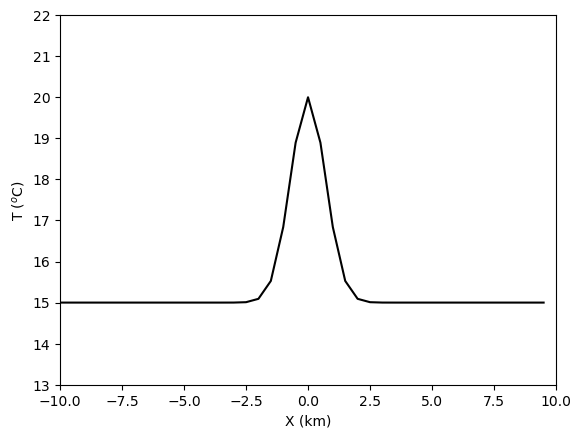

In [2]:
# problem parameters
c=1         # Advection speed [m s-1]
dx=500      # X resolution [m]
dt=200      # time step [s]
t0=0.       # initial time
tmax=0.1    # duration of simulation [days]
xmax=10.0e3 # length of the basin [m]

# Grid definition
# time axis
NT = int(np.floor(tmax*86400/dt))+1  # number of steps (starts from 0)
# X axis (centred at 0)
x = np.arange(-xmax,xmax,dx)
IM = len(x)   # number of grid points
print('grid size : ',IM)
print('number of timesteps : ',NT)

#%% Spatial shape of the temperature disturbance
def Gaussian(x):
    # This is a Gaussian (peak) function with the following params
    T0 = 15         # baseline temperature [degC]
    sigma = 1000.   # width at half amplitude [m]
    A = 5.          # amplitude [degC]
    Gaussian = T0+A*np.exp(-(x/sigma)**2)
    return Gaussian


#%% plot an animation of the temperature disturbance 
fig, ax = plt.subplots()
# set the axis limits and turn off autoscaling
plt.axis([-xmax/1000, xmax/1000, 13, 22])
plt.autoscale(False)
line, = ax.plot(x/1000., Gaussian(x),'k')
ax.set_xlabel('X (km)')
ax.set_ylabel('T ($^o$C)')

def animate(i):
    t = t0 + i*dt
    line.set_ydata(Gaussian(x-c*t))  # update the data.
    return line,

# create the animation (interval is in ms)
ani = animation.FuncAnimation(
    fig, animate, interval=200, blit=True, frames=NT, repeat=True)

# To save the animation, use e.g.
# ani.save("movie.mp4")
# or
# writer = animation.FFMpegWriter(
#     fps=15, metadata=dict(artist='Me'), bitrate=1800)
# ani.save("movie.mp4", writer=writer)

plt.show()

## Changing the values of dx and c

AI Prompt: Can you adapt this code (insert provided code) and plot the curve for different values of dx and c

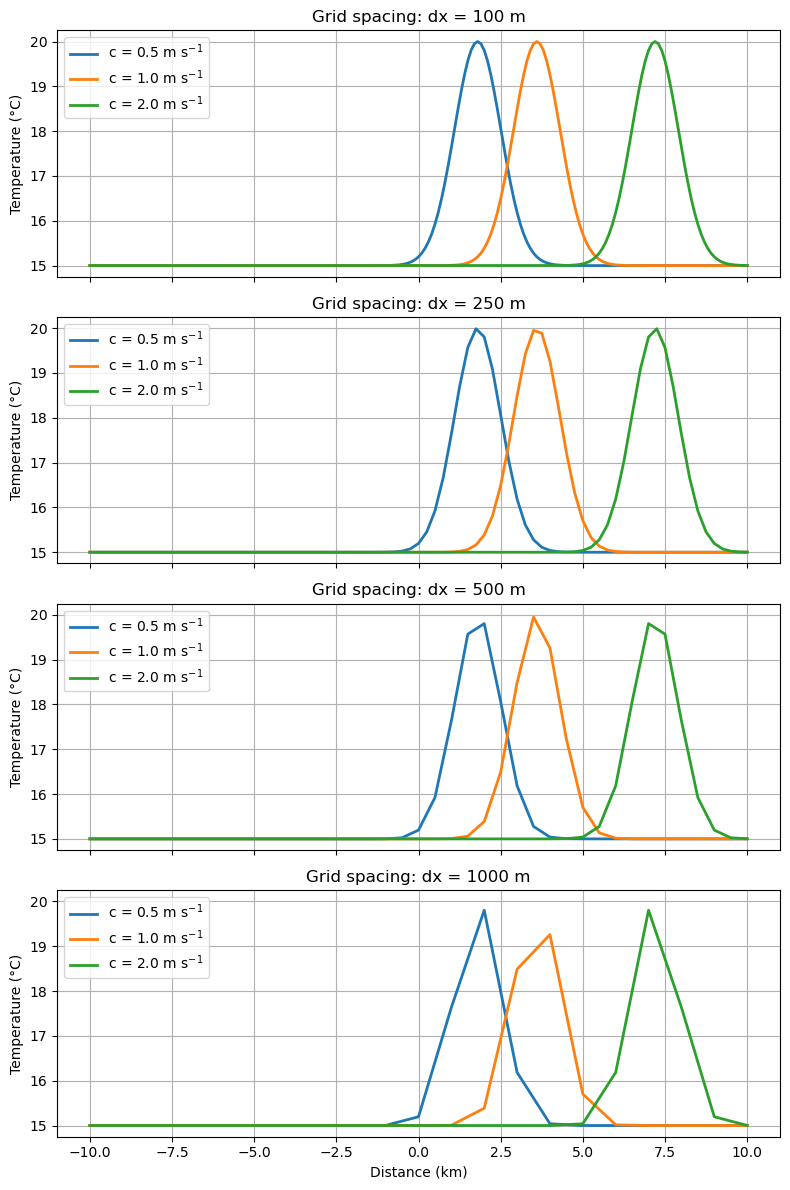

In [5]:
# ---------------------------------------------------
# Model parameters
# ---------------------------------------------------

t_plot = 3600      # Time at which to compare profiles [s]
xmax = 10e3        # Domain half-length [m]

# Parameters to investigate
dx_values = [100, 250, 500, 1000]
c_values = [0.5, 1.0, 2.0]


# ---------------------------------------------------
# Plot
# ---------------------------------------------------

fig, axes = plt.subplots(
    len(dx_values),
    1,
    figsize=(8, 12),
    sharex=True,
    sharey=True
)

for ax, dx in zip(axes, dx_values):

    # Generate grid for this dx
    x = np.arange(-xmax, xmax + dx, dx)

    # Plot each advection speed
    for c in c_values:

        T = Gaussian(x - c * t_plot)

        ax.plot(
            x / 1000,
            T,
            linewidth=2,
            label=f"c = {c} m s$^{{-1}}$"
        )

    ax.set_title(f"Grid spacing: dx = {dx} m")
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Distance (km)")

plt.tight_layout()
plt.show()
plt.show()

### Interpretation of dx and c
The value of c (advection speed) determines how fast the curve advects. So higher values of c allow the curve to travel further in the same time frame.

The value of dx (x resolution) determines how smooth the gaussian curve is. Higher values of dx lead to smoother curves.


## Changing σ

AI Prompt: Can you modify the original code again but plot the different lines for if you increase or decrease the parameter σ

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


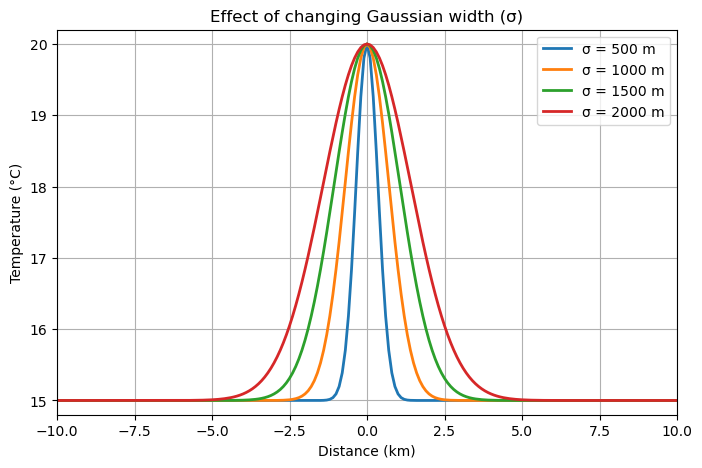

In [8]:

# ---------------------------------------------------
# Problem parameters
# ---------------------------------------------------

xmax = 10.0e3      # domain half-length [m]
dx = 100           # grid spacing [m]

# X axis
x = np.arange(-xmax, xmax + dx, dx)

# Different sigma values to compare
sigma_values = [500, 1000, 1500, 2000]

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

plt.figure(figsize=(8, 5))

for sigma in sigma_values:
    plt.plot(
        x / 1000,
        Gaussian(x, sigma),
        linewidth=2,
        label=f"σ = {sigma} m"
    )

plt.xlabel("Distance (km)")
plt.ylabel("Temperature (°C)")
plt.title("Effect of changing Gaussian width (σ)")
plt.xlim(-10, 10)
plt.ylim(14.8, 20.2)
plt.grid(True)
plt.legend()

plt.show()

### Interpretation of σ
The value of σ determines how broad the curve is.  Larger values give a broader base to the curve.